# **Projet 3 - Prédiction de la consommation énergétique des bâtiments de Seattle**

 * Prédire la consommation énergétique des bâtiments non résidentiels de Seattle à partir de leurs caractéristiques structurelles.
 * Réaliser une analyse exploratoire afin d'identifier les principales tendances et anomalies des données.
 * Comparer plusieurs modèles de régression supervisée pour sélectionner le plus performant.
 * Identifier les variables ayant le plus d'influence sur la consommation énergétique.*
 

## **Objectf** 
Prédire la consommation énergétique (ou les émissions) des bâtiments non résidentiels afin d'aider la ville de Seattle à atteindre la neutralité carbone en 2050.

## **ÉTAPE 2** 

### **Feature engineering**

#### **Importation des Modules**

In [25]:
#importation des librairies

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Importation des librairies OK")

Importation des librairies OK


In [26]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


print("Importation des modules OK")

Importation des modules OK


#### **Chargement du jeu de données**

In [27]:
df = pd.read_csv("../data/processed/buildings_clean.csv")

print("Importation du dataset terminée.")
print(f"Dimensions du dataset : {df.shape[0]} lignes, {df.shape[1]} colonnes")

Importation du dataset terminée.
Dimensions du dataset : 1542 lignes, 32 colonnes


#### **Exploration du jeu de données**

In [28]:
# Aperçu général du dataset

display(df.head())

print(f"Nombre de lignes : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,SiteEnergyUse(kBtu),ComplianceStatus,Outlier,usage_type
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,88434.0,NaN,NaN,NaN,NaN,NaN,7226362.5,Compliant,NaN,Mono-usage
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,83880.0,Parking,15064.0,Restaurant,4622.0,NaN,8387933.0,Compliant,NaN,Multi-usages
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,756493.0,NaN,NaN,NaN,NaN,NaN,72587024.0,Compliant,NaN,Mono-usage
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,61320.0,NaN,NaN,NaN,NaN,NaN,6794584.0,Compliant,NaN,Mono-usage
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,123445.0,Parking,68009.0,Swimming Pool,0.0,NaN,14172606.0,Compliant,NaN,Multi-usages


Nombre de lignes : 1542
Nombre de colonnes : 32


#### **Identification des variables disponibles**
identifier les différentes features disponibles dans le jeu de données.

In [29]:
# Liste des colonnes

pd.set_option("display.max_rows", None)

variable_description = {
    "OSEBuildingID": "Identifiant unique du bâtiment.",
    "DataYear": "Année de collecte des données énergétiques.",
    "BuildingType": "Classification du bâtiment (mono ou multi-usages).",
    "PrimaryPropertyType": "Type principal du bâtiment.",
    "PropertyName": "Nom du bâtiment.",
    "Address": "Adresse du bâtiment.",
    "City": "Ville où se situe le bâtiment.",
    "State": "État.",
    "ZipCode": "Code postal.",
    "TaxParcelIdentificationNumber": "Identifiant cadastral de la parcelle.",
    "CouncilDistrictCode": "Code du district municipal.",
    "Neighborhood": "Quartier où se situe le bâtiment.",
    "Latitude": "Latitude du bâtiment.",
    "Longitude": "Longitude du bâtiment.",
    "YearBuilt": "Année de construction du bâtiment.",
    "NumberofBuildings": "Nombre de bâtiments présents sur la parcelle.",
    "NumberofFloors": "Nombre d'étages.",
    "PropertyGFATotal": "Surface totale du bâtiment.",
    "PropertyGFAParking": "Surface dédiée au parking.",
    "PropertyGFABuilding(s)": "Surface du bâtiment hors parking.",
    "ListOfAllPropertyUseTypes": "Liste des usages du bâtiment.",
    "LargestPropertyUseType": "Usage principal du bâtiment.",
    "LargestPropertyUseTypeGFA": "Surface du principal usage.",
    "SecondLargestPropertyUseType": "Deuxième usage principal.",
    "SecondLargestPropertyUseTypeGFA": "Surface du deuxième usage.",
    "ThirdLargestPropertyUseType": "Troisième usage principal.",
    "ThirdLargestPropertyUseTypeGFA": "Surface du troisième usage.",
    "YearsENERGYSTARCertified": "Année de certification ENERGY STAR.",
    "ENERGYSTARScore": "Score de performance énergétique ENERGY STAR.",
    "SiteEUI(kBtu/sf)": "Intensité de consommation énergétique du site.",
    "SiteEUIWN(kBtu/sf)": "Intensité de consommation énergétique normalisée selon la météo.",
    "SourceEUI(kBtu/sf)": "Intensité de consommation énergétique à la source.",
    "SourceEUIWN(kBtu/sf)": "Intensité de consommation à la source normalisée selon la météo.",
    "SiteEnergyUse(kBtu)": "Consommation énergétique totale annuelle.",
    "SiteEnergyUseWN(kBtu)": "Consommation énergétique annuelle normalisée selon la météo.",
    "SteamUse(kBtu)": "Consommation de vapeur.",
    "Electricity(kWh)": "Consommation d'électricité (kWh).",
    "Electricity(kBtu)": "Consommation d'électricité (kBtu).",
    "NaturalGas(therms)": "Consommation de gaz naturel (therms).",
    "NaturalGas(kBtu)": "Consommation de gaz naturel (kBtu).",
    "TotalGHGEmissions": "Émissions totales de gaz à effet de serre.",
    "GHGEmissionsIntensity": "Intensité des émissions de gaz à effet de serre.",
    "DefaultData": "Indique si les données sont des valeurs par défaut.",
    "Comments": "Commentaires associés au bâtiment.",
    "ComplianceStatus": "Statut de conformité du bâtiment au programme de déclaration énergétique.",
    "Outlier": "Indique si le bâtiment est identifié comme une valeur aberrante."
}

display(pd.DataFrame({
    "Feature": df.columns,
    "Type": df.dtypes.astype(str).values,
    "Description": [variable_description.get(col, "Description non disponible") for col in df.columns]
}))

print(f"Dimensions du dataset : {df.shape[0]} lignes, {df.shape[1]} colonnes")

,Feature,Type,Description
0,OSEBuildingID,int64,Identifiant unique du bâtiment.
1,DataYear,int64,Année de collecte des données énergétiques.
2,BuildingType,str,Classification du bâtiment (mono ou multi-usag...
3,PrimaryPropertyType,str,Type principal du bâtiment.
4,PropertyName,str,Nom du bâtiment.
5,Address,str,Adresse du bâtiment.
6,City,str,Ville où se situe le bâtiment.
7,State,str,État.
8,ZipCode,float64,Code postal.
9,TaxParcelIdentificationNumber,str,Identifiant cadastral de la parcelle.


Dimensions du dataset : 1542 lignes, 32 colonnes


> - Les variables directement liées à la consommation énergétique ont été exclués afin d'éviter tout phénomène de **data leakage**.
> - Les nouvelles features seront principalement issues :
>  des caractéristiques structurelles du bâtiment ;
>  de son ancienneté ;
>  de son usage ;
>  de sa localisation.

### **Feature Engineering - Création des Variables**

#### **Création de la variable BuildingAge** (Temporalité)


> - Transformation de l'année de construction en âge du bâtiment.
> - Cette variable permet de mieux représenter l'ancienneté du bâtiment.
> - Elle est créée sans risque de **data leakage**.

In [30]:
# Création de l'âge du bâtiment

df["BuildingAge"] = df["DataYear"] - df["YearBuilt"]

# Vérification
df[["YearBuilt", "DataYear", "BuildingAge"]].head()

,YearBuilt,DataYear,BuildingAge
0,1927,2016,89
1,1996,2016,20
2,1969,2016,47
3,1926,2016,90
4,1980,2016,36



> - Cette nouvelle variable métier améliore l'interprétation de l'ancienneté des bâtiments et pourra être évaluée lors de l'analyse de corrélation afin de vérifier sa pertinence pour la modélisation.
> - L'âge est plus facilement interprétable que l'année de construction pour expliquer la consommation énergétique

#### **Création de la variable ParkingRatio** (Structure du bâtiment)

> - Calcul de la proportion de la surface dédiée au parking.
> - Cette variable décrit la structure du bâtiment.
> - Elle est créée sans risque de **data leakage**.

In [31]:
# Création du ratio de surface de parking

df["ParkingRatio"] = (
    df["PropertyGFAParking"] / df["PropertyGFATotal"]
)

# Vérification
df[["PropertyGFAParking", "PropertyGFATotal", "ParkingRatio"]].head()

,PropertyGFAParking,PropertyGFATotal,ParkingRatio
0,0,88434,0.000000
1,15064,103566,0.145453
2,196718,956110,0.205748
3,0,61320,0.000000
4,62000,175580,0.353115


> - Cette nouvelle variable métier décrit la part de la surface consacrée au stationnement. Sa pertinence sera vérifiée lors de l'analyse de corrélation.

#### **Création de la variable BuildingRatio** (Structure du bâtiment)

> - Calcul de la proportion de la surface occupée par le bâtiment.
> - Cette variable complète la description de la structure du bâtiment.
> - Elle est créée sans risque de **data leakage**.

In [32]:
# Création du ratio de surface du bâtiment

df["BuildingRatio"] = (
    df["PropertyGFABuilding(s)"] / df["PropertyGFATotal"]
)

# Vérification
df[["PropertyGFABuilding(s)", "PropertyGFATotal", "BuildingRatio"]].head()

,PropertyGFABuilding(s),PropertyGFATotal,BuildingRatio
0,88434,88434,1.000000
1,88502,103566,0.854547
2,759392,956110,0.794252
3,61320,61320,1.000000
4,113580,175580,0.646885


> - Cette variable métier permet de représenter la proportion de surface effectivement construite. Sa pertinence sera évaluée lors de l'analyse de corrélation.

#### **Création de la variable IsMultiUse** (Structure / Usage du bâtiment)

> - Identification des bâtiments ayant plusieurs types d'usages.
> - Cette variable décrit la diversité des usages du bâtiment.
> - Elle est créée sans risque de **data leakage**.

In [33]:
# Création d'une variable binaire indiquant plusieurs usages

df["IsMultiUse"] = (
    df["ListOfAllPropertyUseTypes"]
    .str.contains(",", na=False)
    .astype(int)
)

# Vérification
df[["ListOfAllPropertyUseTypes", "IsMultiUse"]].head()

,ListOfAllPropertyUseTypes,IsMultiUse
0,Hotel,0
1,"Hotel, Parking, Restaurant",1
2,Hotel,0
3,Hotel,0
4,"Hotel, Parking, Swimming Pool",1


> - Cette variable métier simplifie l'information contenue dans les usages du bâtiment et permettra d'évaluer l'influence des bâtiments multi-usages sur la consommation énergétique.

#### **Création de la variable NumberPropertyUses** (Structure / Usage du bâtiment)

> - Comptage du nombre de types d'usages du bâtiment.
> - Cette variable complète l'information apportée par **IsMultiUse**.
> - Elle est créée sans risque de **data leakage**.
> - Cette variable reflète la complexité fonctionnelle du bâtiment.

In [34]:
# Comptage du nombre de types d'usages

df["NumberPropertyUses"] = (
    df["ListOfAllPropertyUseTypes"]
    .str.split(",")
    .str.len()
)

# Vérification
df[["ListOfAllPropertyUseTypes", "NumberPropertyUses"]].head()

,ListOfAllPropertyUseTypes,NumberPropertyUses
0,Hotel,1
1,"Hotel, Parking, Restaurant",3
2,Hotel,1
3,Hotel,1
4,"Hotel, Parking, Swimming Pool",3


> - Cette nouvelle variable métier permet de quantifier la diversité des usages d'un bâtiment et pourra être évaluée lors de l'analyse de corrélation.

#### **Résumé des variables créées lors du Feature Engineering**

In [35]:
# Résumé des variables créées lors du Feature Engineering

feature_summary = pd.DataFrame({
    "Feature créée": [
        "BuildingAge",
        "ParkingRatio",
        "BuildingRatio",
        "IsMultiUse",
        "NumberPropertyUses"
    ],
    "Catégorie": [
        "Temporalité",
        "Structure du bâtiment",
        "Structure du bâtiment",
        "Structure / Usage du bâtiment",
        "Structure / Usage du bâtiment"
    ]
})

display(feature_summary)

,Feature créée,Catégorie
0,BuildingAge,Temporalité
1,ParkingRatio,Structure du bâtiment
2,BuildingRatio,Structure du bâtiment
3,IsMultiUse,Structure / Usage du bâtiment
4,NumberPropertyUses,Structure / Usage du bâtiment


In [36]:
print(f"Dimensions du dataset : {df.shape[0]} lignes, {df.shape[1]} colonnes")

Dimensions du dataset : 1542 lignes, 37 colonnes


### **Analyse de la variable cible**

> -  la distribution de la variable cible est analysée afin d'identifier une éventuelle asymétrie ou la présence de valeurs extrêmes.
> - Cette visualisation permet d'évaluer l'asymétrie de la distribution et de vérifier si une transformation de la variable cible pourra être envisagée lors de la phase de modélisation.

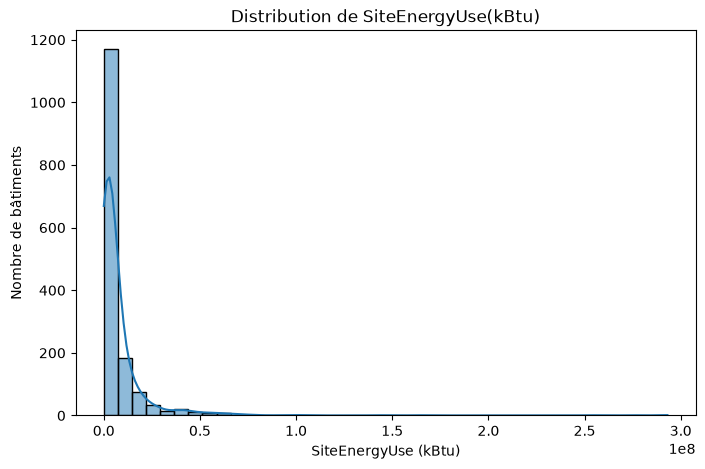

In [37]:
# Distribution de la variable cible

plt.figure(figsize=(8,5))

sns.histplot(
    df["SiteEnergyUse(kBtu)"],
    bins=40,
    kde=True
)

plt.title("Distribution de SiteEnergyUse(kBtu)")
plt.xlabel("SiteEnergyUse (kBtu)")
plt.ylabel("Nombre de bâtiments")

plt.show()

### **Analyse de la corrélation**

> - La matrice de corrélation permet d'identifier les relations linéaires entre les variables numériques après la phase de Feature Engineering.
> - Elle est utilisée pour détecter d'éventuelles variables redondantes avant la modélisation.

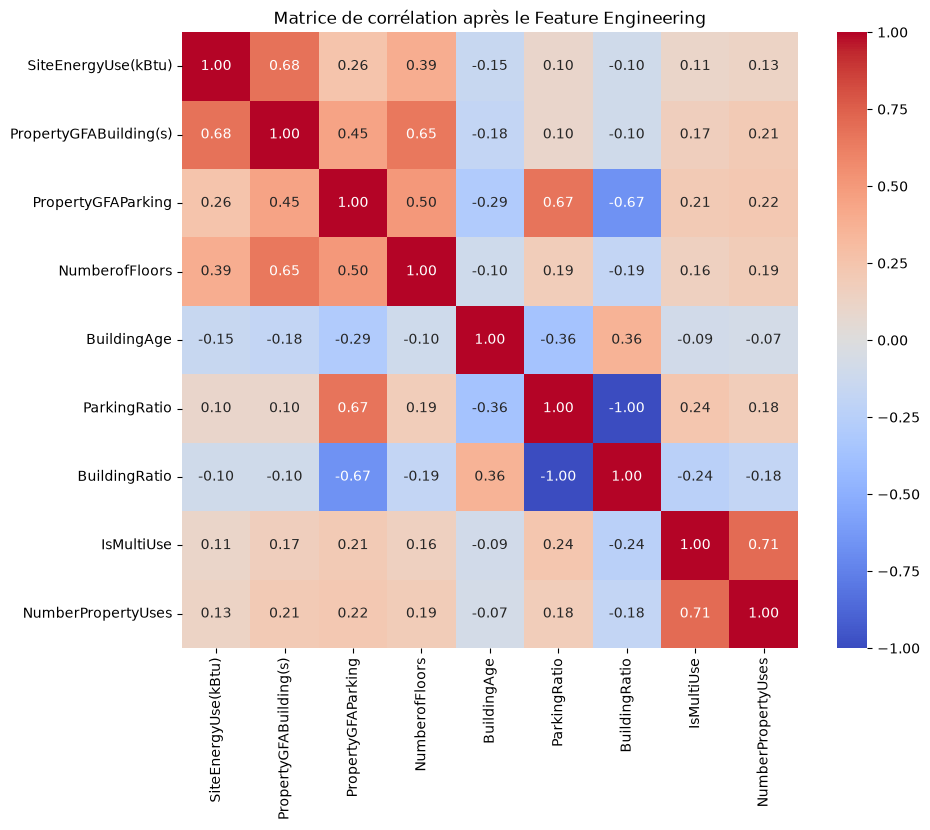

In [38]:
# Matrice de corrélation après le Feature Engineering

correlation_columns = [
    "SiteEnergyUse(kBtu)",
    "PropertyGFABuilding(s)",
    "PropertyGFAParking",
    "NumberofFloors",
    "BuildingAge",
    "ParkingRatio",
    "BuildingRatio",
    "IsMultiUse",
    "NumberPropertyUses"
]

corr = df[correlation_columns].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)

plt.title("Matrice de corrélation après le Feature Engineering")
plt.show()

> - Les variables **PropertyGFABuilding(s)** restent les plus fortement corrélées à la consommation énergétique(0.68).

### **Suppression des variables devenues redondantes**

> - La variable `yearbuilt` est supprimée, car son information est désormais représentée par **BuildingAge**, une variable plus directement interprétable pour les modèles de prédiction.
> - La variable `listofallpropertyusetypes` est supprimée après la création des variables **IsMultiUse** et **NumberPropertyUses**, qui en résument l'information sous une forme plus exploitable.
> - La variable `ParkingRatio` est supprimée en raison de sa corrélation parfaite avec **BuildingRatio** (**r = -1.00**)  Ces deux variables portent la même information ; seule **BuildingRatio** est conservée afin de limiter la redondance et la multicolinéarité.

In [39]:
# Suppression des variables devenues redondantes

df = df.drop(columns=[
    "YearBuilt",
    "ListOfAllPropertyUseTypes",
    "ParkingRatio"
])

print("Variables redondantes supprimées.")
print(f"Dimensions du dataset : {df.shape[0]} lignes, {df.shape[1]} colonnes")

Variables redondantes supprimées.
Dimensions du dataset : 1542 lignes, 34 colonnes


## **Conclusion**

> - Cinq nouvelles variables métier ont été créées afin d'enrichir le jeu de données.
> - Les 3 variables peu pertinentes ainsi que celles susceptibles de provoquer du data leakage ont été supprimées.
> - Le jeu de données est désormais prêt pour la phase de préparation des données.

> Le jeu de données est désormais prêt pour les étapes de préparation des données et de modélisation.

## **Sauvegarde du jeu de données**

In [40]:
from pathlib import Path

Path("../data/processed").mkdir(parents=True, exist_ok=True)

df.to_csv(
    "../data/processed/buildings_features.csv",
    index=False
)

print("Jeu de données sauvegardé avec succès : buildings_features.csv")
print(f"Dimensions du dataset : {df.shape[0]} lignes, {df.shape[1]} colonnes")

Jeu de données sauvegardé avec succès : buildings_features.csv
Dimensions du dataset : 1542 lignes, 34 colonnes
